# تطبيق عملي: خبير البيانات التقليدي مقابل AIDatasetKit

## هل تغير المكتبة علم البيانات أم تنظّم العمل القابل للتفتيش؟

هذا الدفتر يطبق **المهمة نفسها** على البيانات الحقيقية العامة *Online Shoppers Purchasing Intention* من مستودع UCI. الغرض ليس إعلان فائز بين طريقتين؛ بل إظهار ما يفعله خبير البيانات يدويًا باستخدام `pandas` و`scikit-learn`، وما الذي تنسّقه AIDatasetKit وتحتفظ به قابلاً للفحص.

> **السؤال العملي:** هل يمكننا توقع ما إذا كانت جلسة تسوق إلكتروني ستنتهي بشراء (`Revenue=True`) من سمات الجلسة؟

المجموعة تضم 12,330 جلسة، و1,908 جلسة موجبة (15.5% تقريبًا). وهي منشورة بترخيص CC BY 4.0، وقد شكّلها أصحابها بحيث تنتمي كل جلسة إلى مستخدم مختلف خلال سنة واحدة.[1] [2]

**حدود هذا الدفتر:** لا توجد cross-validation أو hyperparameter tuning أو AutoML. لا يثبت هذا التحليل سبب الشراء، ولا يثبت ملاءمة النموذج في متجر آخر، ولا يحوّل احتمالًا/مقياسًا إلى قرار عمل تلقائي.

## أهداف التعلّم

بعد تنفيذ الدفتر ستستطيع أن تميّز بين أربع مسؤوليات: تحديد معنى المتغيرات، منع التسرب بين التدريب والتقييم، بناء preprocessing مناسب للنموذج، وتفسير المقاييس مع عدم توازن الهدف. سترى أيضًا أن AIDatasetKit لا يلغي الحكم البشري: نعلن أن رموز `OperatingSystems` و`Browser` و`Region` و`TrafficType` **فئات** رغم أنها مخزنة كأعداد؛ المكتبة تسجل هذا كاختيار محلل بدل أن تخمّنه.

| جانب العمل | المسار التقليدي لخبير البيانات | مسار AIDatasetKit |
|---|---|---|
| دلالة الأعمدة | يختارها الخبير ويبني قوائم الأعمدة | تبقى قرارًا صريحًا في `PreprocessingConfig` ومسجلًا في الخطة |
| التقسيم | ينشئه الخبير بـ`train_test_split` ويتأكد من stratification | ترسم المكتبة تقسيمًا مشتركًا وتخزّن بصمته |
| preprocessing | يركّب `ColumnTransformer` و`Pipeline` يدويًا | تبني خطة وفق capabilities النموذج، ثم تلائمها على صفوف التدريب فقط |
| الجودة | يفحصها الخبير بأوامر منفصلة | `profile()` و`check_quality()` يقدمان نتائج قابلة للفحص قبل التدريب |
| المقارنة | يكتب حلقة ونظام مقاييس وترتيب | `compare_models()` يطبق النماذج على التقسيم المشترك مع metric معلن |
| القرار العلمي | يفسر النتائج ويقرر ما ينبغي فعله | **يبقى مسؤولية بشرية؛ لا اختيار أو tuning تلقائي** |


In [1]:
from pathlib import Path
import hashlib
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from aidatasetkit import AIDataFacade
from aidatasetkit.core import KitConfig
from aidatasetkit.models import ModelFactory
from aidatasetkit.preprocessing import PreprocessingConfig

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = ["Noto Sans Arabic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.3
pandas: 3.0.5
scikit-learn: 1.9.0


## 1. تحميل بيانات عامة محلية والتحقق من الأصل

الملف حُمل مرة واحدة من رابط UCI الرسمي وحُفظ مع الدفتر لتصبح إعادة التنفيذ **غير معتمدة على الشبكة**. البصمة التالية تحدد نسخة CSV المستخدمة، وليست حكمًا علميًا على البيانات.[1]


In [2]:
CASE_DIR = Path.cwd()
if not (CASE_DIR / "data" / "online_shoppers_intention.csv").exists():
    CASE_DIR = Path("case_studies/online_shoppers")
DATA_PATH = CASE_DIR / "data" / "online_shoppers_intention.csv"
assert DATA_PATH.exists(), f"لم يُعثر على البيانات في {DATA_PATH.resolve()}"

EXPECTED_SHA256 = "d8e130ba51532985f93281a73ce299e6ce150cb915769a7962a11e595eadd6a1"
actual_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert actual_sha256 == EXPECTED_SHA256, "بصمة CSV لا تطابق النسخة الموثقة للدراسة"

data = pd.read_csv(DATA_PATH)
TARGET = "Revenue"
print("المسار:", DATA_PATH.resolve())
print("SHA-256:", actual_sha256)
print("الشكل:", data.shape)
data.head()

المسار: /home/ubuntu/AIDatasetKit/case_studies/online_shoppers/data/online_shoppers_intention.csv
SHA-256: d8e130ba51532985f93281a73ce299e6ce150cb915769a7962a11e595eadd6a1
الشكل: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
overview = pd.DataFrame(
    {
        "القيمة": [
            len(data),
            data.shape[1] - 1,
            int(data.isna().sum().sum()),
            int(data.duplicated().sum()),
            int(data[TARGET].sum()),
            float(data[TARGET].mean()),
        ]
    },
    index=[
        "عدد الجلسات", "عدد الخصائص", "الخلايا المفقودة", "الصفوف المكررة",
        "جلسات Revenue=True", "نسبة الشراء"
    ],
)
overview

,القيمة
عدد الجلسات,12330.000000
عدد الخصائص,17.000000
الخلايا المفقودة,0.000000
الصفوف المكررة,125.000000
جلسات Revenue=True,1908.000000
نسبة الشراء,0.154745


,Revenue,sessions,share
0,False,10422,0.845255
1,True,1908,0.154745


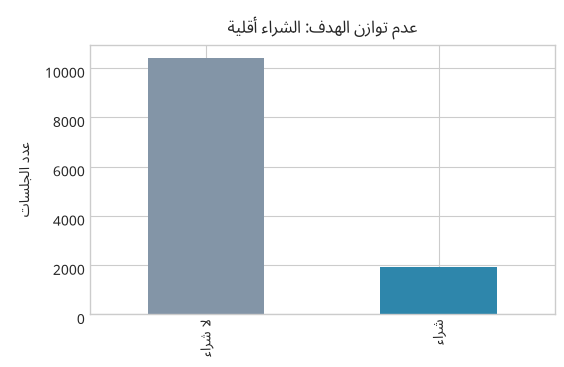

In [4]:
target_counts = data[TARGET].value_counts().rename_axis("Revenue").reset_index(name="sessions")
target_counts["share"] = target_counts["sessions"] / len(data)
display(target_counts)

ax = target_counts.assign(label=target_counts["Revenue"].map({False: "لا شراء", True: "شراء"})).plot.bar(
    x="label", y="sessions", legend=False, color=["#8395a7", "#2e86ab"], figsize=(6, 3.5)
)
ax.set_title("عدم توازن الهدف: الشراء أقلية")
ax.set_xlabel("")
ax.set_ylabel("عدد الجلسات")
plt.show()

## 2. فهم المخطط: قرار الخبير الذي لا ينبغي إخفاؤه

متغيرات `OperatingSystems` و`Browser` و`Region` و`TrafficType` أعداد في CSV، لكنها **رموز فئوية وليست مقاييس ذات مسافة**. معاملتها كأعداد متصلة يوحي خطأً بأن المتصفح 13 «أكبر» أو «أبعد» علميًا من المتصفح 2. لذلك نعاملها كفئات، وكذلك `Month` و`VisitorType` و`Weekend`.

هذا قرار دلالي خارجي عن الملف نفسه. في المسار التقليدي يكتبه الخبير في قائمتي features؛ وفي AIDatasetKit يمرره عبر `nominal_features` كي يصبح جزءًا صريحًا من خطة المعالجة.

In [5]:
NOMINAL_FEATURES = (
    "Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Weekend",
)
NUMERIC_FEATURES = [column for column in data.columns if column not in set(NOMINAL_FEATURES) | {TARGET}]
roles = pd.DataFrame(
    {
        "الدور التحليلي": ["فئوي/اسمي"] * len(NOMINAL_FEATURES) + ["عددي"] * len(NUMERIC_FEATURES),
        "نوع pandas": [str(data[column].dtype) for column in NOMINAL_FEATURES + tuple(NUMERIC_FEATURES)],
        "عدد القيم المميزة": [data[column].nunique() for column in NOMINAL_FEATURES + tuple(NUMERIC_FEATURES)],
    },
    index=list(NOMINAL_FEATURES) + NUMERIC_FEATURES,
)
roles

,الدور التحليلي,نوع pandas,عدد القيم المميزة
Month,فئوي/اسمي,str,10
OperatingSystems,فئوي/اسمي,int64,8
Browser,فئوي/اسمي,int64,13
Region,فئوي/اسمي,int64,9
TrafficType,فئوي/اسمي,int64,20
VisitorType,فئوي/اسمي,str,3
Weekend,فئوي/اسمي,bool,2
Administrative,عددي,int64,27
Administrative_Duration,عددي,float64,3335
Informational,عددي,int64,17


## 3. بروتوكول مقارنة عادل

لكي لا نقارن نتائج صادرة عن صفوف تقييم مختلفة، نستخدم البذرة `42`، ونسبة تقييم `20%`، وstratification على `Revenue` في كلا المسارين. المسار اليدوي يستدعي `train_test_split` مباشرة، ثم نتحقق من تطابق مواقع الصفوف مع بصمة تقسيم AIDatasetKit لاحقًا.

نستخدم **Logistic Regression نفسها وبالمعلمات نفسها** (`max_iter=1000`, `random_state=42`) للمقارنة العددية الأساسية. بعد ذلك نعرض **كل كتالوج التصنيف المنشور حاليًا** داخل AIDatasetKit من دون tuning أو تغيير للمعلمات الافتراضية؛ يبقى الانحدار اللوجستي هو نقطة المقارنة العددية المتكافئة مع المسار اليدوي.

In [6]:
X = data.drop(columns=TARGET)
y = data[TARGET]
positions = np.arange(len(data))
manual_train_positions, manual_eval_positions = train_test_split(
    positions,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y,
)
manual_train_positions = np.sort(manual_train_positions)
manual_eval_positions = np.sort(manual_eval_positions)
X_train, X_eval = X.iloc[manual_train_positions], X.iloc[manual_eval_positions]
y_train, y_eval = y.iloc[manual_train_positions], y.iloc[manual_eval_positions]
print(f"التدريب: {len(X_train):,} صف | التقييم: {len(X_eval):,} صف")
print("نسبة الشراء في التدريب/التقييم:", round(y_train.mean(), 4), round(y_eval.mean(), 4))

التدريب: 9,864 صف | التقييم: 2,466 صف
نسبة الشراء في التدريب/التقييم: 0.1547 0.1549


## 4. المسار التقليدي: ما يبنيه خبير `scikit-learn` يدويًا

هذا مسار صحيح ومألوف، لكنه يحمل قائمة مسؤوليات صريحة: عدم ملاءمة imputer أو scaler أو encoder على التقييم، معالجة الفئات غير المرئية، اختيار المقاييس الإيجابية، وحفظ إعدادات التقسيم والمعالجة. لا يوجد شيء «أقل علمية» في هذا المسار؛ الفرق هو مقدار التنسيق والتسجيل الذي يتعين على الخبير القيام به بنفسه.

In [7]:
manual_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            list(NOMINAL_FEATURES),
        ),
    ],
    remainder="drop",
)
manual_model = Pipeline(
    [
        ("preprocess", manual_preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)
manual_model.fit(X_train, y_train)
manual_predictions = manual_model.predict(X_eval)
positive_position = list(manual_model.classes_).index(True)
manual_probabilities = manual_model.predict_proba(X_eval)[:, positive_position]
manual_metrics = {
    "accuracy": accuracy_score(y_eval, manual_predictions),
    "precision": precision_score(y_eval, manual_predictions, pos_label=True, zero_division=0),
    "recall": recall_score(y_eval, manual_predictions, pos_label=True, zero_division=0),
    "f1": f1_score(y_eval, manual_predictions, pos_label=True, zero_division=0),
    "roc_auc": roc_auc_score(y_eval, manual_probabilities),
}
manual_matrix = manual_model.named_steps["preprocess"].transform(X_train)
print("عدد ميزات النموذج بعد one-hot:", manual_matrix.shape[1])
pd.Series(manual_metrics, name="مسار خبير scikit-learn")

عدد ميزات النموذج بعد one-hot: 75


accuracy     0.880779
precision    0.736559
recall       0.358639
f1           0.482394
roc_auc      0.882787
Name: مسار خبير scikit-learn, dtype: float64

**تفسير مختصر للمقاييس.** مع أن accuracy مهمة، فإن الأغلبية لا تشتري؛ لذلك لا تكفي وحدها. `precision` يسأل: من الجلسات التي تنبأ النموذج أنها شراء، كم كان شراءً؟ و`recall` يسأل: من جلسات الشراء الفعلية، كم التقط النموذج؟ و`F1` يوازن بينهما، بينما ROC-AUC يقيس قدرة ترتيب الدرجات عبر عتبات مختلفة. لا تحدد هذه الأرقام وحدها تكلفة إرسال عرض تسويقي أو قرار عمل مناسب.

## 5. مسار AIDatasetKit: التنسيق القابل للفحص

نمرر **القرار الدلالي نفسه** و**البذرة نفسها** إلى المكتبة. بعدها نفصل صراحة بين profile والجودة والتحضير والمقارنة والتدريب والتقييم. `prepare()` يخطط ولا يلائم شيئًا؛ ولا تختار المكتبة النموذج بدلنا. نطلب النماذج ونختار `logistic_regression` صراحة كي تكون المقارنة العددية مع المسار اليدوي عادلة.

In [8]:
config = KitConfig(random_state=42, validation_size=0.20)
preprocessing_config = PreprocessingConfig(nominal_features=NOMINAL_FEATURES)
ai = AIDataFacade(
    target=TARGET,
    task="classification",
    positive_label=True,
    config=config,
    preprocessing_config=preprocessing_config,
)
ai.load(data)
profile = ai.profile()
quality = ai.check_quality()

print("المهمة المحلولة:", ai.task.value)
print("عدد الصفوف من profile:", profile.row_count)
print("حكم الجودة:", ai.verdict.value)
print("عدد القضايا:", quality.issue_count)

quality_table = pd.DataFrame([issue.to_dict() for issue in quality.issues])
quality_table[["severity", "code", "column", "requires_review", "recommendation"]].head(15)

المهمة المحلولة: classification
عدد الصفوف من profile: 12330
حكم الجودة: review_required
عدد القضايا: 11


,severity,code,column,requires_review,recommendation
0,warning,duplicate_rows,NaN,False,Confirm whether the repetition is genuine or a...
1,info,possible_outliers,Administrative,True,"These are candidates, not errors. Extreme valu..."
2,info,possible_outliers,Administrative_Duration,True,"These are candidates, not errors. Extreme valu..."
3,info,possible_outliers,ProductRelated,True,"These are candidates, not errors. Extreme valu..."
4,info,possible_outliers,ProductRelated_Duration,True,"These are candidates, not errors. Extreme valu..."
5,info,possible_outliers,BounceRates,True,"These are candidates, not errors. Extreme valu..."
6,info,possible_outliers,ExitRates,True,"These are candidates, not errors. Extreme valu..."
7,info,possible_outliers,OperatingSystems,True,"These are candidates, not errors. Extreme valu..."
8,info,possible_outliers,Region,True,"These are candidates, not errors. Extreme valu..."
9,info,possible_outliers,TrafficType,True,"These are candidates, not errors. Extreme valu..."


النتيجة `review_required` ليست فشلًا تقنيًا. إنها تقول إن بعض النتائج heuristic تستحق أن يراجعها إنسان. في هذه البيانات لا توجد خلايا مفقودة في المصدر، لكن فحص الجودة لا يفترض أن «لا شيء يحتاج نظرًا»؛ والدفتر لا يتجاوز الفحص أو يخفيه.

In [9]:
plans = ai.prepare()
plan_payloads = {str(key): value.to_dict() for key, value in plans.items()}
plan_table = pd.DataFrame(
    [
        {
            "preprocessing profile": profile_key,
            "excluded features": len(payload.get("excluded_features", [])),
            "review features": len(payload.get("review_features", [])),
            "target": payload.get("target_name"),
        }
        for profile_key, payload in plan_payloads.items()
    ]
)
print("عدد خطط المعالجة المتميزة:", len(plans))
plan_table

عدد خطط المعالجة المتميزة: 5


,preprocessing profile,excluded features,review features,target
0,"scaling=0,sparse=0,native_nan=1",0,0,Revenue
1,"scaling=0,sparse=1,native_nan=1",0,0,Revenue
2,"scaling=1,sparse=0,native_nan=0",0,0,Revenue
3,"scaling=0,sparse=1,native_nan=0",0,0,Revenue
4,"scaling=1,sparse=1,native_nan=0",0,0,Revenue


In [10]:
MODELS = ModelFactory.available(task="classification")
comparison = ai.compare_models(models=MODELS)
assert len(MODELS) == 9, "تغير كتالوج التصنيف؛ راجع نتائج هذا الدفتر"

comparison_table = pd.DataFrame(
    [
        {
            "model": outcome.model_name,
            "succeeded": outcome.succeeded,
            "f1": None if outcome.evaluation is None else outcome.evaluation["f1"].value,
            "accuracy": None if outcome.evaluation is None else outcome.evaluation["accuracy"].value,
            "roc_auc": None if outcome.evaluation is None else outcome.evaluation["roc_auc"].value,
            "failure_reason": outcome.failure_reason,
        }
        for outcome in comparison.outcomes
    ]
)
print("مقياس ترتيب المقارنة المعلن:", comparison.ranking_metric)
print("ترتيب هذه التجربة المحدودة:", [outcome.model_name for outcome in comparison.ranked])
comparison_table.sort_values("f1", ascending=False)

مقياس ترتيب المقارنة المعلن: f1
ترتيب هذه التجربة المحدودة: ['gradient_boosting_classifier', 'hist_gradient_boosting_classifier', 'random_forest_classifier', 'decision_tree_classifier', 'extra_trees_classifier', 'knn_classifier', 'logistic_regression', 'gaussian_nb', 'dummy_classifier']


,model,succeeded,f1,accuracy,roc_auc,failure_reason
4,gradient_boosting_classifier,True,0.643777,0.899027,0.928307,None
5,hist_gradient_boosting_classifier,True,0.641135,0.897405,0.925836,None
8,random_forest_classifier,True,0.583333,0.894566,0.914075,None
0,decision_tree_classifier,True,0.557717,0.861719,0.739667,None
2,extra_trees_classifier,True,0.499127,0.883617,0.883018,None
6,knn_classifier,True,0.489933,0.876723,0.763258,None
7,logistic_regression,True,0.482394,0.880779,0.882787,None
3,gaussian_nb,True,0.293260,0.272912,0.733405,None
1,dummy_classifier,True,0.000000,0.845093,0.500000,None


يجب أن يقرأ هذا الترتيب بدقة: هو **الأعلى في F1 لهذه البيانات، وهذا التقسيم، وهذه المعلمات**. ليس «أفضل نموذج» عامًّا، وليس بحثًا عن hyperparameters، ولا بديلًا عن تحقق خارجي أو فهم تكلفة الخطأ.

In [11]:
ai.select_model("logistic_regression")
training = ai.train()
evaluation = ai.evaluate()
kit_metrics = {name: evaluation[name].value for name in ("accuracy", "precision", "recall", "f1", "roc_auc")}

same_train_rows = np.array_equal(manual_train_positions, comparison.split.train_positions)
same_eval_rows = np.array_equal(manual_eval_positions, comparison.split.evaluation_positions)
assert same_train_rows and same_eval_rows, "المقارنة لم تستخدم الصفوف نفسها"

print("بصمة التقسيم المشتركة:", comparison.split.fingerprint)
print("تطابق صفوف التدريب والتقييم مع المسار اليدوي:", same_train_rows and same_eval_rows)
print("عدد الميزات بعد معالجة AIDatasetKit:", training.transformed_feature_count)
pd.Series(kit_metrics, name="مسار AIDatasetKit")

بصمة التقسيم المشتركة: e9c1bdb70a4fede1
تطابق صفوف التدريب والتقييم مع المسار اليدوي: True
عدد الميزات بعد معالجة AIDatasetKit: 75


accuracy     0.880779
precision    0.736559
recall       0.358639
f1           0.482394
roc_auc      0.882787
Name: مسار AIDatasetKit, dtype: float64

## 6. مقارنة النتائج: نفس المهمة، نفس الصفوف، نفس الانحدار اللوجستي

النتيجة الرقمية المتطابقة هنا نتيجة متوقعة ومفيدة: أعطينا الطريقتين التقسيم نفسه، والأدوار نفسها، والاستراتيجيات نفسها، والنموذج نفسه. لذلك يثبت التمرين أن AIDatasetKit لا يضيف «سحرًا» أو علمًا موازيًا؛ بل يجعل قرارات orchestration والجودة والقدرات والتقسيم قابلة للفحص والتسجيل.

,خبير scikit-learn,AIDatasetKit,فرق مطلق
accuracy,0.880779,0.880779,0.0
precision,0.736559,0.736559,0.0
recall,0.358639,0.358639,0.0
f1,0.482394,0.482394,0.0
roc_auc,0.882787,0.882787,0.0


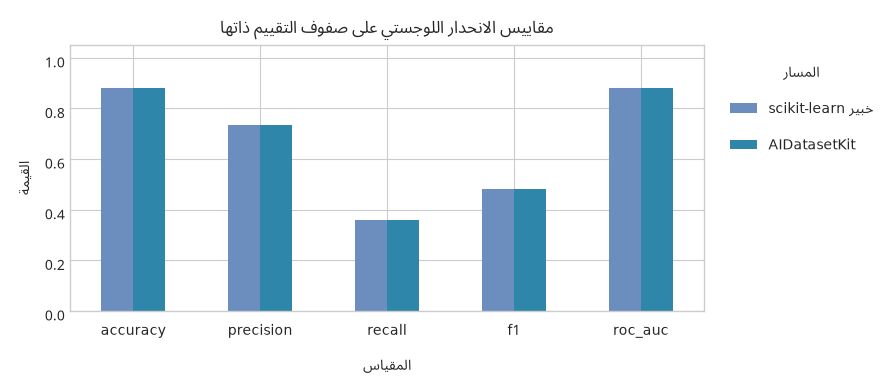

In [12]:
results_table = pd.DataFrame(
    {
        "خبير scikit-learn": manual_metrics,
        "AIDatasetKit": kit_metrics,
    }
)
results_table["فرق مطلق"] = (results_table["خبير scikit-learn"] - results_table["AIDatasetKit"]).abs()
display(results_table)
assert np.allclose(results_table["فرق مطلق"].to_numpy(), 0.0), "ينبغي تطابق النتيجة في هذه المقارنة المضبوطة"

ax = results_table[["خبير scikit-learn", "AIDatasetKit"]].plot.bar(
    figsize=(9, 4), ylim=(0, 1.05), rot=0, color=["#6c8ebf", "#2e86ab"]
)
ax.set_title("مقاييس الانحدار اللوجستي على صفوف التقييم ذاتها")
ax.set_xlabel("المقياس")
ax.set_ylabel("القيمة")
plt.legend(title="المسار", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. ما الذي يظل قرارًا بشريًا؟

| سؤال | ما فعله الدفتر/المكتبة | ما لا يمكن تفويضه تلقائيًا |
|---|---|---|
| هل الرموز العددية فئات؟ | سجلناها كـ`nominal_features` | الحكم الدلالي على معنى الرمز |
| هل جودة البيانات مقبولة؟ | أعطى `check_quality()` قضايا وحكمًا | تفسير القضايا وسياق العمل |
| ما مقياس النجاح؟ | حسبنا F1 وROC-AUC ومقاييس أخرى | تكلفة false positives/false negatives |
| هل النموذج جاهز للنشر؟ | لا تدعي المكتبة ذلك | تحقق زمني/خارجي، مراقبة، حوكمة، قرار المؤسسة |
| هل توجد سببية؟ | لا | تصميم تجريبي أو دراسة سببية مناسبة |

لا توجد بيانات تعريف شخصية في الملف المنشور، لكن هذا لا يجعل أي نموذج أو مخرجاته «مضمونة الخصوصية». كما أن تنبؤ الشراء لا يساوي تفسير نية إنسان أو سببها.

## 8. الخلاصة القابلة للتكرار

- البيانات حقيقية وعامة ومرخصة CC BY 4.0؛ الإسناد مطلوب عند إعادة الاستخدام.[1] [2]
- المسار اليدوي يوضح مكوّنات `scikit-learn` التي يجب على الخبير أن يركّبها ويحرس حدودها بنفسه.
- AIDatasetKit ينسق المسار نفسه، ويجعل profile والجودة وخطط المعالجة وبصمة التقسيم ونتائج النماذج أشياء قابلة للتفتيش.
- لا تضيف المكتبة cross-validation أو tuning أو اختيارًا تلقائيًا؛ لذلك لا ينبغي قراءة هذه النتيجة كتقييم نهائي لنموذج أعمال.

## المراجع

[1] [UCI Machine Learning Repository — Online Shoppers Purchasing Intention Dataset](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention)؛ 12,330 جلسة، الهدف `Revenue`، وترخيص CC BY 4.0.

[2] Sakar, C. & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset*. UCI Machine Learning Repository. [https://doi.org/10.24432/C5F88Q](https://doi.org/10.24432/C5F88Q).

[3] [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/).
